<a href="https://colab.research.google.com/github/231018412-cpu/CSE443assignment/blob/main/problem1/problem1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import EfficientNetB4

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import class_weight

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
train_dir = "/content/drive/MyDrive/Archive/train"
val_dir   = "/content/drive/MyDrive/Archive/val"
test_dir  = "/content/drive/MyDrive/Archive/test"

In [15]:
for folder in [train_dir,val_dir,test_dir]:

    print("\nDataset:",folder)

    for cls in os.listdir(folder):

        path = os.path.join(folder,cls)

        print(cls,"=",len(os.listdir(path)))


Dataset: /content/drive/MyDrive/Archive/train
PNEUMONIA = 3875
NORMAL = 1341

Dataset: /content/drive/MyDrive/Archive/val
PNEUMONIA = 9
NORMAL = 8

Dataset: /content/drive/MyDrive/Archive/test
NORMAL = 234
PNEUMONIA = 390


In [16]:
IMG_SIZE = (380,380)
BATCH = 16

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,

    zoom_range=0.2,

    shear_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
train_gen = train_datagen.flow_from_directory(

    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(

    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(

    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [18]:
labels = train_gen.classes

class_weights = class_weight.compute_class_weight(

    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [19]:
base_model = EfficientNetB4(

    weights="imagenet",
    include_top=False,
    input_shape=(380,380,3)
)

base_model.trainable = False

In [20]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256,activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(1,activation="sigmoid")(x)

model = Model(inputs=base_model.input,outputs=output)

In [21]:
loss = tf.keras.losses.BinaryFocalCrossentropy()

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss=loss,

    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 380, 380,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 380, 380,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 380, 380,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 18,140,256 (69.20 MB)

 Trainable params: 462,849 (1.77 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(

    monitor="val_loss",
    patience=2,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=3
)

checkpoint = ModelCheckpoint(

    "best_model.h5",

    monitor="val_accuracy",

    save_best_only=True
)

In [23]:
history = model.fit(

    train_gen,

    epochs=8,

    validation_data=val_gen,

    class_weight=class_weights,

    callbacks=[early_stop,reduce_lr,checkpoint]
)

Epoch 1/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4882 - loss: 0.2800

326/326 ━━━━━━━━━━━━━━━━━━━━ 1674s 5s/step - accuracy: 0.4908 - loss: 0.2649 - val_accuracy: 0.3333 - val_loss: 0.1795 - learning_rate: 1.0000e-04
Epoch 2/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.4915 - loss: 0.2436

326/326 ━━━━━━━━━━━━━━━━━━━━ 272s 835ms/step - accuracy: 0.4983 - loss: 0.2349 - val_accuracy: 0.5833 - val_loss: 0.1718 - learning_rate: 1.0000e-04
Epoch 3/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 270s 827ms/step - accuracy: 0.5054 - loss: 0.2152 - val_accuracy: 0.3333 - val_loss: 0.1792 - learning_rate: 1.0000e-04
Epoch 4/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 315s 805ms/step - accuracy: 0.5082 - loss: 0.2061 - val_accuracy: 0.5833 - val_loss: 0.1720 - learning_rate: 1.0000e-04


In [24]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'PYTHON (112.5).pptx', 'Application Software & Their Usages_Group G.pptx', "I am sharing 'paraphrasing and summary' with you.pdf", 'lab', 'Document from Srabonti Chowdhury', 'Share class code', "I am sharing 'AA 200.7 (Resume) (1)' with you.pdf", "I am sharing 'AA 200.7 (Cover Letter)' with you (1).pdf", "I am sharing 'AA 200.7 (Cover Letter)' with you.pdf", '231018412', "I am sharing 'Response paper Srabonti(231018412) -AA099.4.docx' with you.pdf", 'Response paper .pdf', "I am sharing 'Response paper srabonti(231018412) -AA099.4' with you.pdf", "I am sharing 'Cover page AA099' with you.pdf", '16950095758141554694712385866267.jpg', 'L-4 Skills.gslides', 'CamScanner 10-08-2023 16.13.pdf', 'MATH-207.2hw-1.pdf', 'CamScanner 11-03-2023 14.33 (2).pdf', 'CamScanner 11-03-2023 14.33 (1).pdf', 'CamScanner 11-03-2023 14.33.pdf', 'CamScanner 04-28-2023 12.02.pdf', 'CamScanner 11-04-2023 23.24.pdf', '231018412 ,Cse212.2.pdf', '231018412cse212.2(string report).pdf', '231018412cselab2

In [25]:
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

train_dir = "/content/drive/MyDrive/Archive/train"
val_dir   = "/content/drive/MyDrive/Archive/val"
test_dir  = "/content/drive/MyDrive/Archive/test"

IMG_SIZE = (380,380)
BATCH = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [26]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [27]:
labels = train_gen.classes

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

In [3]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

base_model = EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(380,380,3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256,activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1,activation="sigmoid")(x)
model = Model(inputs=base_model.input,outputs=output)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

loss = tf.keras.losses.BinaryFocalCrossentropy()

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=loss,
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 18,140,256 (69.20 MB)

 Trainable params: 462,849 (1.77 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [28]:
base_model.trainable = True

for layer in base_model.layers[:-40]:

    layer.trainable = False

model.compile(

    optimizer=Adam(1e-5),

    loss=loss,

    metrics=["accuracy"]
)

history_fine = model.fit(

    train_gen,

    epochs=10,

    validation_data=val_gen,

    class_weight=class_weights
)

Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 378s 944ms/step - accuracy: 0.4941 - loss: 0.4311 - val_accuracy: 0.3333 - val_loss: 0.2177
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 264s 809ms/step - accuracy: 0.5096 - loss: 0.3785 - val_accuracy: 0.6250 - val_loss: 0.1612
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 257s 787ms/step - accuracy: 0.5079 - loss: 0.3654 - val_accuracy: 0.6667 - val_loss: 0.1654
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 255s 782ms/step - accuracy: 0.5188 - loss: 0.3245 - val_accuracy: 0.5417 - val_loss: 0.1660
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 256s 786ms/step - accuracy: 0.5322 - loss: 0.2936 - val_accuracy: 0.3333 - val_loss: 0.1968
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 258s 790ms/step - accuracy: 0.5408 - loss: 0.2812 - val_accuracy: 0.5417 - val_loss: 0.1860
Epoch 7/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 254s 778ms/step - accuracy: 0.5370 - loss: 0.2746 - val_accuracy: 0.5417 - val_loss: 0.1640
Epoch 8/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 256s 784ms/step - accuracy: 0.5610 -

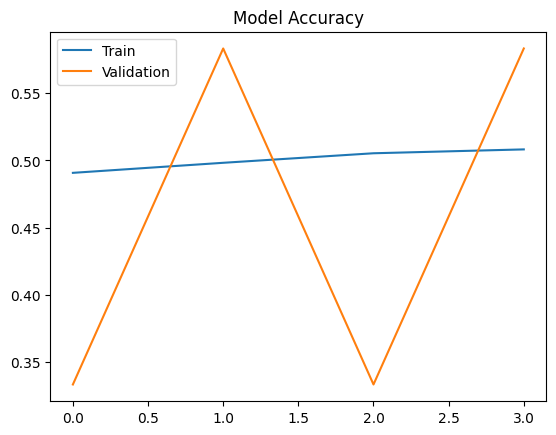

In [29]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [30]:
test_loss,test_acc = model.evaluate(test_gen)

print("Test Accuracy =",test_acc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.6538 - loss: 0.1525
Test Accuracy = 0.6538461446762085


39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step


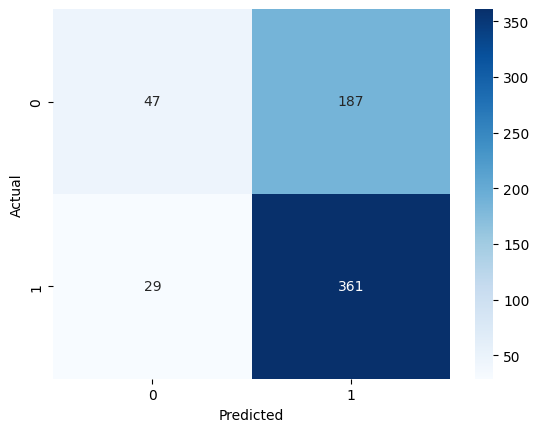

              precision    recall  f1-score   support

           0       0.62      0.20      0.30       234
           1       0.66      0.93      0.77       390

    accuracy                           0.65       624
   macro avg       0.64      0.56      0.54       624
weighted avg       0.64      0.65      0.59       624



In [31]:
pred = model.predict(test_gen)

pred_class = np.where(pred>0.5,1,0)

true = test_gen.classes

cm = confusion_matrix(true,pred_class)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(true,pred_class))